In [1]:
import sys
sys.path.append("..")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.Linear_Regression import LinearRegression
from src.preprocessing import prepare_data, error_analysis, get_feature_names, add_bias

# Data Processing

In [3]:
X_train_processed, X_test_processed, y_train, y_test, X_train, X_test, house_data = prepare_data()

print("Training data shape:", X_train_processed.shape)
print("Test data shape:", X_test_processed.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)



Training data shape: (64000, 28)
Test data shape: (16000, 28)
Training labels shape: (64000,)
Test labels shape: (16000,)


In [4]:
numerical_features, categorical_features, encoded_features, processed_features_name = get_feature_names()

print("# numerical features:", len(numerical_features))
print("Numerical features:", numerical_features)
print("\n")
print("# encoded features:", len(encoded_features))
print("Encoded features:", encoded_features)
print("\n")
print("# processed features:", len(processed_features_name))
print("Processed features:", processed_features_name)

# numerical features: 12
Numerical features: ['BHK', 'Bathrooms', 'Super_Area_SqFt', 'Carpet_Area_SqFt', 'Floor_Number', 'Total_Floors', 'Age_of_Property', 'Parking', 'Lift_Available', 'Gated_Community', 'Distance_to_Metro_km', 'Distance_to_City_Center_km']


# encoded features: 16
Encoded features: ['City_Bangalore' 'City_Chandigarh' 'City_Chennai' 'City_Delhi'
 'City_Hyderabad' 'City_Jaipur' 'City_Kolkata' 'City_Mumbai' 'City_Pune'
 'Locality_Type_Mid-Range' 'Locality_Type_Premium'
 'Property_Type_Builder Floor' 'Property_Type_Independent House'
 'Property_Type_Villa' 'Furnishing_Status_Semi-Furnished'
 'Furnishing_Status_Unfurnished']


# processed features: 28
Processed features: ['BHK', 'Bathrooms', 'Super_Area_SqFt', 'Carpet_Area_SqFt', 'Floor_Number', 'Total_Floors', 'Age_of_Property', 'Parking', 'Lift_Available', 'Gated_Community', 'Distance_to_Metro_km', 'Distance_to_City_Center_km', 'City_Bangalore', 'City_Chandigarh', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jai

# 3.1 Linear Regression

In [5]:
X_train_bias, X_test_bias = add_bias(X_train_processed, X_test_processed)

print("Training data shape with bias term:", X_train_bias.shape)
print("Test data shape with bias term:", X_test_bias.shape)

Training data shape with bias term: (64000, 29)
Test data shape with bias term: (16000, 29)


In [6]:
lr_model = LinearRegression()
lr_model.fit(X_train_bias, y_train)

In [7]:
print("# of parameters:", lr_model.theta.shape[0])
for feature_name, coefficient in zip(["Intercept"] + processed_features_name, lr_model.theta):
    print(f"{feature_name}: {coefficient}")

# of parameters: 29
Intercept: 49.398426036861345
BHK: -0.7144117169493328
Bathrooms: 0.21161674420013968
Super_Area_SqFt: 70.80560591340733
Carpet_Area_SqFt: -1.3889841540907917
Floor_Number: 0.0662364726495305
Total_Floors: -0.21560125413691938
Age_of_Property: -15.916401279123408
Parking: 1.5538871149200673
Lift_Available: 1.1903189575973938
Gated_Community: 1.561613252542932
Distance_to_Metro_km: 0.8797459897807316
Distance_to_City_Center_km: -13.353581820132538
City_Bangalore: 75.4896656753646
City_Chandigarh: 52.02094549291417
City_Chennai: 47.031234569345955
City_Delhi: 152.46321041036668
City_Hyderabad: 41.35546785519619
City_Jaipur: -10.21756881390125
City_Kolkata: 24.152283255422407
City_Mumbai: 232.13322154268818
City_Pune: 58.21040531780834
Locality_Type_Mid-Range: 9.799785902257392
Locality_Type_Premium: 80.64761331614733
Property_Type_Builder Floor: 0.20207118299254276
Property_Type_Independent House: -0.29796443118964744
Property_Type_Villa: 1.1495058562000882
Furnishing

In [8]:
y_pred = lr_model.predict(X_test_bias)

In [9]:
error = y_test - y_pred
error_analysis(y_test, y_pred)

Mean Absolute Error (MAE): 47.94025405073612
Mean Squared Error (MSE): 7400.387020983882
Root Mean Squared Error (RMSE): 86.0255021547906
R-squared: 0.6657463774890664


In [10]:
abs_error = np.abs(error.to_numpy())
largest_errors_indices = np.argsort(abs_error)[-10:][::-1]

print("Largest errors (absolute):", abs_error[largest_errors_indices])

Largest errors (absolute): [2666.51426689 1692.81141374 1656.80531094 1576.86940361 1489.5410502
 1426.09377353 1373.651024   1222.48279151 1162.86688389 1153.08925131]


In [11]:
largest_error_rows = X_test.iloc[largest_errors_indices].copy()

largest_error_rows["Actual Price"] = y_test.iloc[largest_errors_indices]
largest_error_rows["Predicted Price"] = y_pred[largest_errors_indices]
largest_error_rows["Absolute Error"] = abs_error[largest_errors_indices]


print(largest_error_rows)

            City Locality_Type  Property_Type  BHK  Bathrooms  \
29399     Mumbai       Premium          Villa    2          2   
27989     Mumbai       Premium  Builder Floor    6          6   
76198      Delhi       Premium          Villa    2          3   
28319     Mumbai       Premium  Builder Floor    4          5   
70498      Delhi       Premium          Villa    2          2   
5784      Mumbai       Premium      Apartment    4          5   
48752      Delhi       Premium      Apartment    2          3   
15940     Mumbai     Mid-Range  Builder Floor    2          3   
65667  Bangalore       Premium  Builder Floor    3          3   
31684      Delhi       Premium      Apartment    5          6   

       Super_Area_SqFt  Carpet_Area_SqFt  Floor_Number  Total_Floors  \
29399          2821.13           2388.03            29            35   
27989          1970.04           1426.31            18            27   
76198          2533.38           2033.48             8            16

In [12]:
condition_number_term = np.linalg.cond(
    X_train_bias.T @ X_train_bias
)

condition_number_X = np.linalg.cond(
    X_train_bias
)


print("Condition number of the design matrix:", condition_number_term)
print("Condition number of the X:", condition_number_X)

Condition number of the design matrix: 231.1372861808773
Condition number of the X: 15.20319986650434


Removing Carpet_Area_SqFt

In [13]:
current_features = processed_features_name.copy()

In [14]:
def remove_feature(X_train, X_test, feature_names, feature_to_remove):
    index = feature_names.index(feature_to_remove)
    X_train_new = np.delete(
        X_train,
        index,
        axis=1
    )
    X_test_new = np.delete(
        X_test,
        index,
        axis=1
    )

    feature_names_new = [
        feature
        for i, feature in enumerate(feature_names)
        if i != index
    ]

    return X_train_new, X_test_new, feature_names_new


In [15]:
X_train_no_carpet, X_test_no_carpet, current_features = remove_feature(X_train_processed, X_test_processed, current_features, "Carpet_Area_SqFt")

print("Shape of training data after removing 'Carpet_Area_SqFt':", X_train_no_carpet.shape)
print("Shape of test data after removing 'Carpet_Area_SqFt':", X_test_no_carpet.shape)

Shape of training data after removing 'Carpet_Area_SqFt': (64000, 27)
Shape of test data after removing 'Carpet_Area_SqFt': (16000, 27)


In [16]:
X_train_no_carpet_bias, X_test_no_carpet_bias = add_bias(X_train_no_carpet, X_test_no_carpet)

print("Shape of training data with bias term after removing 'Carpet_Area_SqFt':", X_train_no_carpet_bias.shape)
print("Shape of test data with bias term after removing 'Carpet_Area_SqFt':", X_test_no_carpet_bias.shape)

Shape of training data with bias term after removing 'Carpet_Area_SqFt': (64000, 28)
Shape of test data with bias term after removing 'Carpet_Area_SqFt': (16000, 28)


In [17]:
lr_model_no_carpet = LinearRegression()
lr_model_no_carpet.fit(X_train_no_carpet_bias, y_train)

In [18]:
y_pred_no_carpet = lr_model_no_carpet.predict(X_test_no_carpet_bias)

In [19]:
error_analysis(y_test, y_pred_no_carpet)

Mean Absolute Error (MAE): 47.93976767116538
Mean Squared Error (MSE): 7399.878515733125
Root Mean Squared Error (RMSE): 86.02254655456979
R-squared: 0.6657693451692228


Making y_train into Log(y+1) form 

In [20]:
y_train_log = np.log1p(y_train)

In [21]:
lr_model_log = LinearRegression()
lr_model_log.fit(X_train_bias, y_train_log)

In [22]:
y_pred_log = lr_model_log.predict(X_test_bias)

y_pred_org = np.expm1(y_pred_log)

In [23]:
error_analysis(y_test, y_pred_org)

Mean Absolute Error (MAE): 34.8199306273559
Mean Squared Error (MSE): 5570.264303662621
Root Mean Squared Error (RMSE): 74.63420330962622
R-squared: 0.748407614822956


In [24]:
abs_errors_log_model = np.abs(y_test.to_numpy() - y_pred_org)
largest_error_indices_log = np.argsort(abs_errors_log_model)[-10:][::-1]

largest_error_rows_log = X_test.iloc[largest_error_indices_log].copy()
largest_error_rows_log["Actual_Price"] = y_test.iloc[largest_error_indices_log].values
largest_error_rows_log["Predicted_Price"] = y_pred_org[largest_error_indices_log]
largest_error_rows_log["Absolute_Error"] = abs_errors_log_model[largest_error_indices_log]

print(largest_error_rows_log[["City","Locality_Type","Super_Area_SqFt","Actual_Price","Predicted_Price","Absolute_Error"]])



            City Locality_Type  Super_Area_SqFt  Actual_Price  \
29399     Mumbai       Premium          2821.13   3216.463936   
27989     Mumbai       Premium          1970.04   2118.077564   
76198      Delhi       Premium          2533.38   2066.850917   
28319     Mumbai       Premium          2116.70   2015.136967   
70498      Delhi       Premium          2604.39   1888.725648   
48752      Delhi       Premium          2164.92   1744.789814   
15940     Mumbai     Mid-Range          1588.83   1564.522651   
5784      Mumbai       Premium          2743.20   1922.444303   
65667  Bangalore       Premium          2526.23   1519.327700   
31684      Delhi       Premium          2488.40   1563.814016   

       Predicted_Price  Absolute_Error  
29399      1068.081836     2148.382100  
27989       479.584235     1638.493329  
76198       532.189932     1534.660985  
28319       525.299157     1489.837810  
70498       482.250966     1406.474682  
48752       421.975739     1322.814075

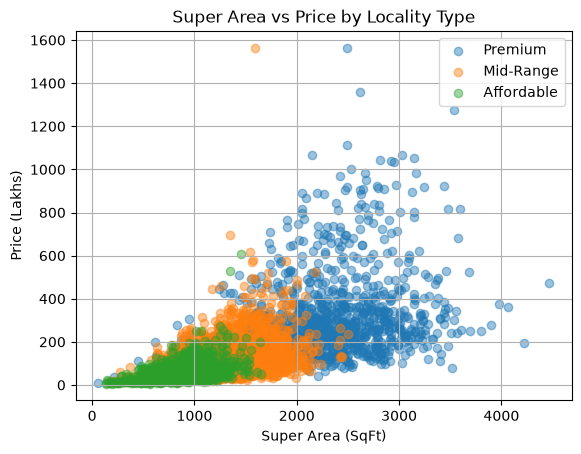

In [28]:
plt.Figure(figsize=[6,8])

plot_data = house_data.sample(n=5000, random_state=42)

for locality in plot_data["Locality_Type"].unique():
    subset = plot_data[plot_data["Locality_Type"] == locality]

    plt.scatter(
        subset["Super_Area_SqFt"],
        subset["Price_INR_Lakhs"],
        label = locality,
        alpha=0.45
    )

plt.xlabel("Super Area (SqFt)")
plt.ylabel("Price (Lakhs)")
plt.title("Super Area vs Price by Locality Type")
plt.grid(True)
plt.legend()
plt.show()